In [1]:
import os
import re
from pathlib import Path

import imageio.v2 as imageio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime, timedelta

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
SAMPLING_MINUTES = 5

def extract_timestamp_from_name(path_like):
    match = re.search(r"(\d{8}_\d{4})", Path(path_like).stem)
    if match is None:
        return None
    return datetime.strptime(match.group(1), "%Y%m%d_%H%M")

def list_image_files(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Cartella non trovata: {folder}")

    image_files = [
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    records = []
    skipped_files = []
    for path in image_files:
        timestamp = extract_timestamp_from_name(path)
        if timestamp is None:
            skipped_files.append(path.name)
            continue
        records.append({
            "name": path.name,
            "path": str(path),
            "relative_dir": str(path.parent.relative_to(folder)),
            "datetime": timestamp,
        })

    if not records:
        raise RuntimeError(f"Nessuna immagine valida trovata in {folder}")

    files_df = pd.DataFrame(records).sort_values(["datetime", "name", "path"]).reset_index(drop=True)
    return files_df, skipped_files

In [2]:
cartella = Path("/media/isacDisk2/source_dataset")  # Modifica con il tuo percorso
df_files, skipped_files = list_image_files(cartella)

file_names = df_files["name"].tolist()
timestamps = df_files["datetime"].tolist()

print(f"Cartella analizzata: {cartella}")
print(f"Immagini valide trovate: {len(df_files)}")
print(f"Sottocartelle con immagini: {df_files['relative_dir'].nunique()}")
if skipped_files:
    print(f"File ignorati senza timestamp valido: {len(skipped_files)}")
    print(skipped_files[:10])

df_files.head()


Cartella analizzata: /media/isacDisk2/source_dataset
Immagini valide trovate: 951799
Sottocartelle con immagini: 123


,name,path,relative_dir,datetime
0,airmass_rgb_20101011_0005.png,/media/isacDisk2/source_dataset/2010/10/airmas...,2010/10,2010-10-11 00:05:00
1,airmass_rgb_20101011_0010.png,/media/isacDisk2/source_dataset/2010/10/airmas...,2010/10,2010-10-11 00:10:00
2,airmass_rgb_20101011_0015.png,/media/isacDisk2/source_dataset/2010/10/airmas...,2010/10,2010-10-11 00:15:00
3,airmass_rgb_20101011_0020.png,/media/isacDisk2/source_dataset/2010/10/airmas...,2010/10,2010-10-11 00:20:00
4,airmass_rgb_20101011_0025.png,/media/isacDisk2/source_dataset/2010/10/airmas...,2010/10,2010-10-11 00:25:00


In [3]:
df = df_files[["name", "path", "relative_dir", "datetime"]].copy()

# Le stripe blu devono rappresentare timestamp unici davvero consecutivi a passo di 5 minuti.
df_unique = (
    df.sort_values(["datetime", "path"])
    .drop_duplicates(subset=["datetime"], keep="first")
    .reset_index(drop=True)
)

df_unique["diff"] = df_unique["datetime"].diff().dt.total_seconds() / 60
df_unique["new_block"] = df_unique["diff"].isna() | ((df_unique["diff"] - SAMPLING_MINUTES).abs() > 1e-9)
df_unique["block_id"] = df_unique["new_block"].cumsum()

blocks = (
    df_unique.groupby("block_id")
    .agg(
        start=("datetime", "first"),
        end=("datetime", "last"),
        num_timestamps=("datetime", "size"),
    )
    .reset_index(drop=True)
)

blocks["duration_minutes"] = ((blocks["end"] - blocks["start"]).dt.total_seconds() / 60).astype(int)
blocks["expected_timestamps"] = (blocks["duration_minutes"] / SAMPLING_MINUTES).astype(int) + 1

# Le lacune sono i punti in cui il salto temporale non e` di 5 minuti.
gaps = df_unique.loc[df_unique["new_block"] & df_unique["diff"].notna(), ["datetime", "diff"]].copy()
gaps.rename(columns={"diff": "gap_minutes"}, inplace=True)

print(f"Immagini valide totali: {len(df)}")
print(f"Timestamp unici usati per le stripe: {len(df_unique)}")
print(f"Blocchi continui trovati (step esatto {SAMPLING_MINUTES} min): {len(blocks)}")
print(f"Primo timestamp: {df_unique['datetime'].min()}")
print(f"Ultimo timestamp: {df_unique['datetime'].max()}")
blocks.head()


Immagini valide totali: 951799
Timestamp unici usati per le stripe: 951799
Blocchi continui trovati (step esatto 5 min): 1265
Primo timestamp: 2010-10-11 00:05:00
Ultimo timestamp: 2023-12-31 23:20:00


,start,end,num_timestamps,duration_minutes,expected_timestamps
0,2010-10-11 00:05:00,2010-10-11 11:05:00,133,660,133
1,2010-10-11 11:15:00,2010-10-13 23:55:00,729,3640,729
2,2011-01-01 00:00:00,2011-01-11 09:10:00,2991,14950,2991
3,2011-01-13 08:05:00,2011-01-25 15:30:00,3546,17725,3546
4,2011-01-25 15:40:00,2011-02-03 19:45:00,2642,13205,2642


In [4]:
gaps

,datetime,gap_minutes
133,2010-10-11 11:15:00,10.0
862,2011-01-01 00:00:00,113765.0
3853,2011-01-13 08:05:00,2815.0
7399,2011-01-25 15:40:00,10.0
10041,2011-02-03 19:55:00,10.0
...,...,...
940361,2023-11-20 06:40:00,15.0
940663,2023-11-21 07:55:00,10.0
940669,2023-11-21 08:30:00,10.0
944711,2023-12-07 08:40:00,2845.0


In [5]:
df_med = pd.read_csv('../moduli/videomae/medicane_data_input/medicane_validi.csv')

In [6]:
df_med_named = df_med[df_med['Medicane']!='Unnamed']
df_med_named.reset_index()[['Medicane', 'Start_Date', 'End_Date']]

,Medicane,Start_Date,End_Date
0,Rolf,2011-11-03,2011-11-09
1,Ilona,2014-01-19,2014-01-22
2,Qendresa,2014-11-04,2014-11-11
3,Trixie,2016-10-26,2016-11-02
4,Numa,2017-11-14,2017-11-20
5,Zorbas,2018-09-25,2018-10-01
6,Ianos,2020-09-14,2020-09-22
7,Apollo,2021-10-24,2021-11-02
8,Blas,2021-11-06,2021-11-16
9,Helios,2023-02-08,2023-02-11


In [7]:
df_med_named.to_csv("medicane_validi.csv")

Plot salvato in: check_downloaded_timespan.png


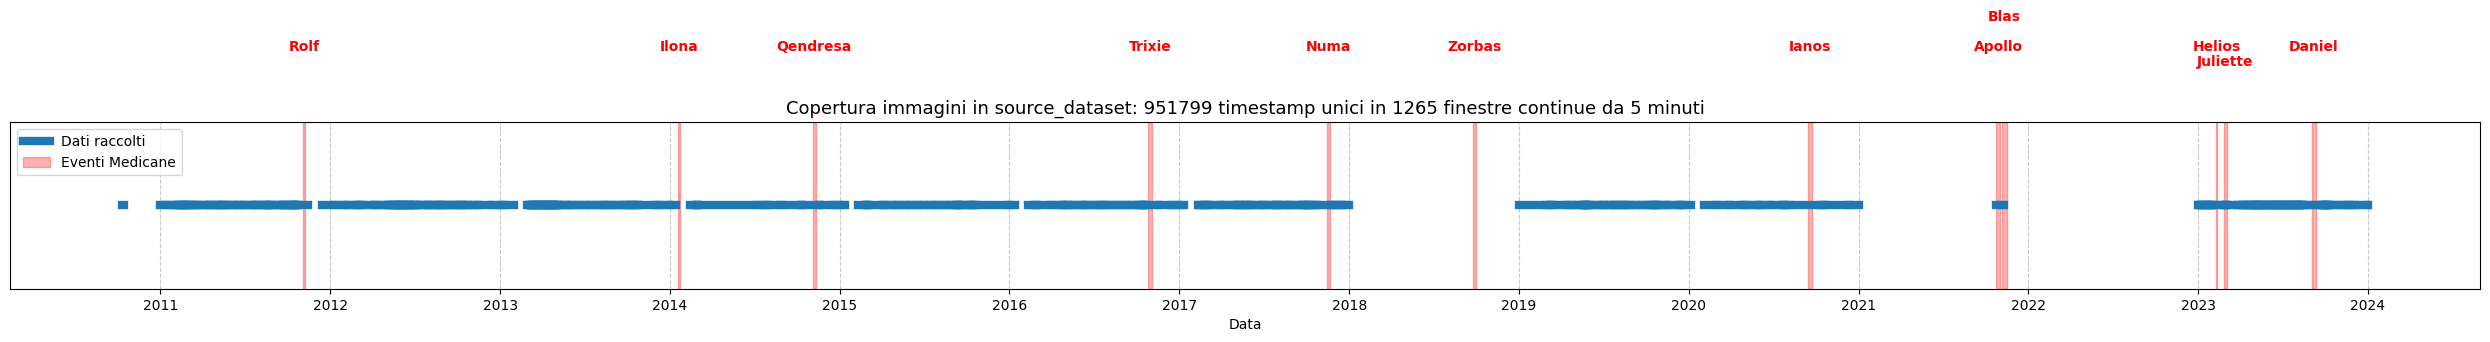

In [8]:
df_med_named = df_med_named.copy()

# Assicurarsi che le date siano in formato datetime
df_med_named["Start_Date"] = pd.to_datetime(df_med_named["Start_Date"])
df_med_named["End_Date"] = pd.to_datetime(df_med_named["End_Date"])

# Creazione del grafico con i blocchi temporali e gli eventi dei medicane con gestione delle etichette
fig, ax = plt.subplots(figsize=(25, 3), tight_layout=True)

# Disegnare i blocchi temporali dei dati raccolti
ax.plot([], [], linewidth=6, color="tab:blue", label="Dati raccolti")
for _, row in blocks.iterrows():
    ax.plot([row["start"], row["end"]], [1, 1], linewidth=6, color="tab:blue")

# Disegnare gli eventi medicane e aggiungere etichette leggibili
ax.fill_between([], [], color="red", alpha=0.3, label="Eventi Medicane")
prev_x = None
offset = 0.02

for _, row in df_med_named.iterrows():
    ax.axvspan(row["Start_Date"], row["End_Date"], color="red", alpha=0.3)
    mid_point = row["Start_Date"] + (row["End_Date"] - row["Start_Date"]) / 2

    if prev_x is not None and abs((mid_point - prev_x).days) < 100:
        y_pos = 1.1 + offset
        offset *= -0.5
    else:
        y_pos = 1.1
    prev_x = mid_point

    ax.text(mid_point, y_pos, row["Medicane"], ha="center", va="bottom", fontsize=10, color="red", fontweight="bold")

ax.set_title(
    f"Copertura immagini in {cartella.name}: {len(df_unique)} timestamp unici in {len(blocks)} finestre continue da {SAMPLING_MINUTES} minuti",
    fontsize=13,
)
ax.set_xlabel("Data")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_yticks([])
ax.grid(True, axis="x", linestyle="--", alpha=0.7)
ax.legend(loc="upper left")

plot_output = Path("check_downloaded_timespan.png")
fig.savefig(plot_output, dpi=150, bbox_inches="tight")
print(f"Plot salvato in: {plot_output}")
plt.show()


Numero finestre continue: 1265
Durata totale finestre contigue: 9 anni, 0 mesi, 15 giorni (arrotondato al giorno)
Durata massima finestra: 3047.42 ore
Durata mediana finestra: 3.58 ore
Frame mediani per finestra: 44


,start,end,num_timestamps,duration_minutes,expected_timestamps,duration_hours,duration_days
807,2014-03-02 11:40:00,2014-07-07 11:05:00,36570,182845,36570,3047.416667,126.975694
855,2015-10-22 01:00:00,2015-12-31 23:50:00,20435,102170,20435,1702.833333,70.951389
1009,2020-08-03 10:00:00,2020-10-12 11:15:00,20176,100875,20176,1681.250000,70.052083
942,2019-01-01 00:00:00,2019-03-03 11:35:00,17708,88535,17708,1475.583333,61.482639
1011,2020-10-21 05:25:00,2020-12-11 00:15:00,14627,73130,14627,1218.833333,50.784722
811,2014-08-27 07:15:00,2014-10-10 11:05:00,12719,63590,12719,1059.833333,44.159722
796,2013-10-25 06:20:00,2013-12-01 18:10:00,10799,53990,10799,899.833333,37.493056
814,2014-10-12 11:15:00,2014-11-17 15:50:00,10424,52115,10424,868.583333,36.190972
860,2016-02-27 11:40:00,2016-03-30 10:00:00,9197,45980,9197,766.333333,31.930556
828,2015-03-02 11:40:00,2015-04-03 08:20:00,9177,45880,9177,764.666667,31.861111


,duration_minutes,duration_hours,num_timestamps
count,1265.000000,1265.000000,1265.000000
mean,3757.051383,62.617523,752.410277
std,10279.600879,171.326681,2055.920176
min,0.000000,0.000000,1.000000
25%,10.000000,0.166667,3.000000
50%,215.000000,3.583333,44.000000
75%,1860.000000,31.000000,373.000000
max,182845.000000,3047.416667,36570.000000


Plot durate salvato in: check_downloaded_window_durations.png


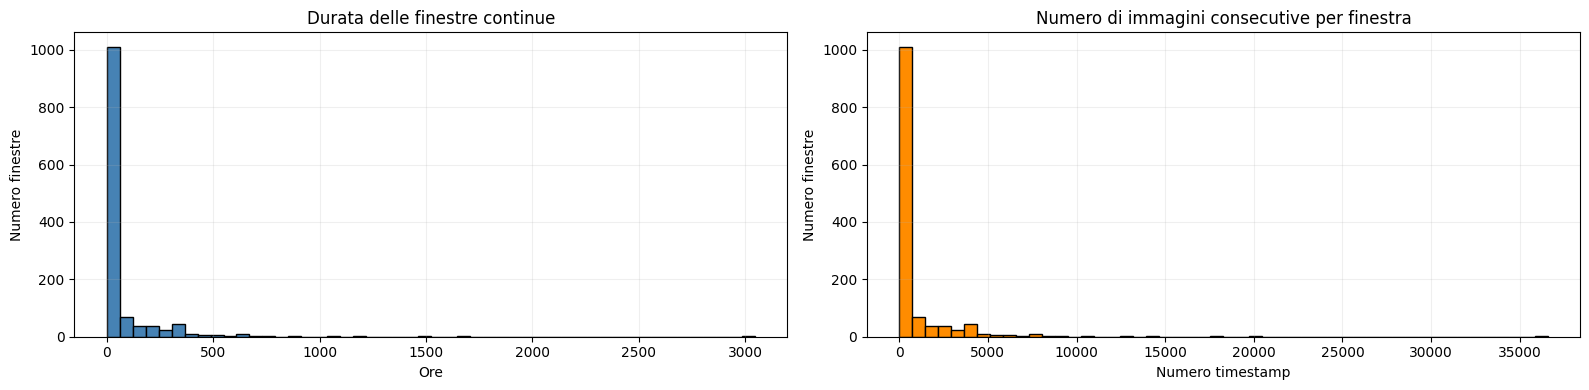

In [9]:
# Diagnostica: durata delle finestre temporali davvero consecutive
window_stats = blocks.copy()
window_stats["duration_hours"] = window_stats["duration_minutes"] / 60
window_stats["duration_days"] = window_stats["duration_minutes"] / (60 * 24)

total_duration_minutes = int(window_stats["duration_minutes"].sum())
total_duration_hours = total_duration_minutes / 60
total_duration_days = total_duration_minutes / (60 * 24)
total_duration_days_rounded = int(round(total_duration_days))
total_years = total_duration_days_rounded // 365
remaining_days = total_duration_days_rounded % 365
total_months = remaining_days // 30
total_days_final = remaining_days % 30
total_duration_ymd = f"{total_years} anni, {total_months} mesi, {total_days_final} giorni"

print(f"Numero finestre continue: {len(window_stats)}")
print(f"Durata totale finestre contigue: {total_duration_ymd} (arrotondato al giorno)")
print(f"Durata massima finestra: {window_stats['duration_hours'].max():.2f} ore")
print(f"Durata mediana finestra: {window_stats['duration_hours'].median():.2f} ore")
print(f"Frame mediani per finestra: {window_stats['num_timestamps'].median():.0f}")

display(window_stats.sort_values('duration_minutes', ascending=False).head(20))
display(window_stats[['duration_minutes', 'duration_hours', 'num_timestamps']].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 4), tight_layout=True)
axes[0].hist(window_stats['duration_hours'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Durata delle finestre continue')
axes[0].set_xlabel('Ore')
axes[0].set_ylabel('Numero finestre')
axes[0].grid(alpha=0.2)

axes[1].hist(window_stats['num_timestamps'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Numero di immagini consecutive per finestra')
axes[1].set_xlabel('Numero timestamp')
axes[1].set_ylabel('Numero finestre')
axes[1].grid(alpha=0.2)

duration_plot_output = Path('check_downloaded_window_durations.png')
fig.savefig(duration_plot_output, dpi=150, bbox_inches='tight')
print(f"Plot durate salvato in: {duration_plot_output}")
plt.show()


Numero di vuoti: 1264
Quota di transizioni che sono vuoti: 0.1328%
Vuoto mediano: 15 minuti
Vuoto massimo: 10023.00 ore
Tempo totale mancante oltre il passo regolare: 1525.11 giorni


,datetime,gap_minutes,missing_minutes_beyond_step,gap_hours,missing_hours_beyond_step
861594,2023-01-01 00:00:00,601380.0,601375.0,10023.000000,10022.916667
655535,2019-01-01 00:00:00,525610.0,525605.0,8760.166667,8760.083333
857452,2021-10-24 00:00:00,426245.0,426240.0,7104.083333,7104.000000
862,2011-01-01 00:00:00,113765.0,113760.0,1896.083333,1896.000000
568595,2017-02-09 09:05:00,43205.0,43200.0,720.083333,720.000000
85724,2011-12-15 08:05:00,43135.0,43130.0,718.916667,718.833333
282974,2014-02-13 08:05:00,43135.0,43130.0,718.916667,718.833333
761723,2020-02-03 09:05:00,40325.0,40320.0,672.083333,672.000000
475533,2016-02-09 09:05:00,40310.0,40305.0,671.833333,671.750000
378946,2015-02-10 08:05:00,40270.0,40265.0,671.166667,671.083333


,gap_minutes,gap_hours,missing_minutes_beyond_step
count,1264.000000,1264.000000,1264.000000
mean,1742.472310,29.041205,1737.472310
std,25820.139341,430.335656,25820.139341
min,10.000000,0.166667,5.000000
25%,10.000000,0.166667,5.000000
50%,15.000000,0.250000,10.000000
75%,30.000000,0.500000,25.000000
max,601380.000000,10023.000000,601375.000000


Istogramma vuoti salvato in: check_downloaded_gap_histogram.png


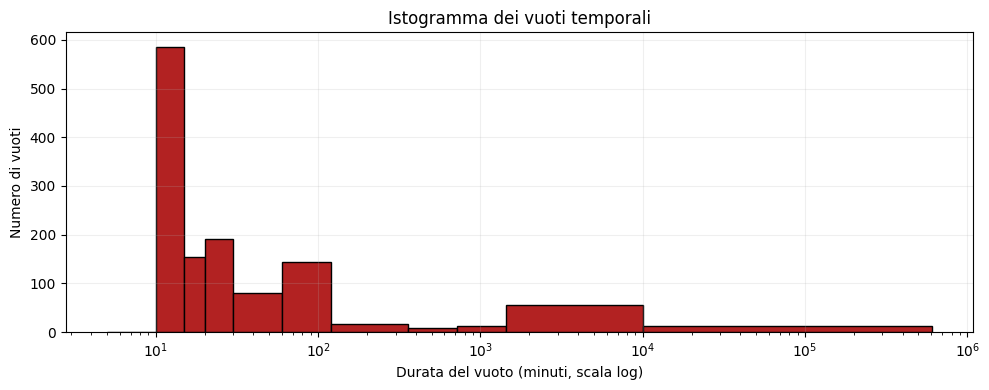

In [10]:
# Diagnostica dei vuoti: pochi come numero, ma possono essere grandi come durata
gap_stats = gaps.copy()
gap_stats['missing_minutes_beyond_step'] = gap_stats['gap_minutes'] - SAMPLING_MINUTES
gap_stats['gap_hours'] = gap_stats['gap_minutes'] / 60
gap_stats['missing_hours_beyond_step'] = gap_stats['missing_minutes_beyond_step'] / 60

print(f"Numero di vuoti: {len(gap_stats)}")
print(f"Quota di transizioni che sono vuoti: {len(gap_stats) / max(len(df_unique) - 1, 1):.4%}")
print(f"Vuoto mediano: {gap_stats['gap_minutes'].median():.0f} minuti")
print(f"Vuoto massimo: {gap_stats['gap_hours'].max():.2f} ore")
print(f"Tempo totale mancante oltre il passo regolare: {gap_stats['missing_hours_beyond_step'].sum() / 24:.2f} giorni")

display(gap_stats.sort_values('gap_minutes', ascending=False).head(20))
display(gap_stats[['gap_minutes', 'gap_hours', 'missing_minutes_beyond_step']].describe())

fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
gap_max = float(gap_stats['gap_minutes'].max())
bins = [5, 10, 15, 20, 30, 60, 120, 360, 720, 1440, 10080, gap_max]
bins = sorted(set(float(b) for b in bins if b <= gap_max))
if len(bins) < 2:
    bins = 20
ax.hist(gap_stats['gap_minutes'], bins=bins, color='firebrick', edgecolor='black')
ax.set_xscale('log')
ax.set_title('Istogramma dei vuoti temporali')
ax.set_xlabel('Durata del vuoto (minuti, scala log)')
ax.set_ylabel('Numero di vuoti')
ax.grid(alpha=0.2)

gap_plot_output = Path('check_downloaded_gap_histogram.png')
fig.savefig(gap_plot_output, dpi=150, bbox_inches='tight')
print(f"Istogramma vuoti salvato in: {gap_plot_output}")
plt.show()
